In [2]:

import argparse
from pathlib import Path
from itertools import product
from concurrent.futures import ProcessPoolExecutor, as_completed

import pandas as pd
from tqdm import tqdm

from gradnorm.eval import (
    STRATEGIES, NORM_TYPES,
    build_strategies, load_trajectories,
    get_param_names_and_sizes, discover_n_layers,
    CompiledConfigs, evaluate_trajectories,
)

In [3]:
import json
import re
from pathlib import Path

import numpy as np
from gradnorm.eval import (
    build_strategies, load_trajectories,
    get_param_names_and_sizes, discover_n_layers,
    CompiledConfigs, score_step,
)

# ── resolve config → CompiledConfigs for just that one config ─────────────────
def _resolve_single_config(config_name, param_names, param_sizes):
    """Find config_name across all strategies and compile it."""
    # peek at n_layers so build_strategies works
    n_layers = discover_n_layers(param_names)
    all_strats = build_strategies(n_layers)
    for strat_dict in all_strats.values():
        if config_name in strat_dict:
            return CompiledConfigs.compile(
                {config_name: strat_dict[config_name]},
                param_names, param_sizes,
            )

# ── load ww data → filename → reason ─────────────────────────────────────────
def _load_ww_reasons(ww_dir: Path, subset: str) -> dict[str, str | None]:
    """Map filename → mistake_reason from raw ww JSONs."""
    reasons = {}
    for fp in sorted((ww_dir / subset).glob("*.json")):
        raw = json.loads(fp.read_text())
        reasons[fp.name] = raw.get("mistake_reason")
    return reasons

# records[:3]   # preview

In [14]:
# ── inputs ────────────────────────────────────────────────────────────────────
# SUBSET       = "algorithm-generated"          # or "algorithm-generated"
# SUBSET = "hand-crafted"
# SCORE_CONFIG = "mlp/35"                  # e.g. layer/35, mlp/20, v/35, lm_head …
# NORM_TYPE    = "l2_norm"               # "l1_norm" | "l2_norm"
# GRADNORM_DIR = Path("outputs/gradnorm/qwen3-8b-full")   # adjust model as needed
# WW_DIR       = Path("ww")
# K            = 3

SUBSET = "hand-crafted"
SCORE_CONFIG = "lm_head"                  # e.g. layer/35, mlp/20, v/35, lm_head …
NORM_TYPE    = "l2_norm"               # "l1_norm" | "l2_norm"
GRADNORM_DIR = Path("outputs/gradnorm-losses/qwen3-8b-kl_uniform")   # adjust model as needed
WW_DIR       = Path("ww")
K            = 3


In [8]:
import pandas as pd
from pathlib import Path

ABLATION_DIR = Path("outputs/gradnorm-losses")
SUBSETS = ["algorithm-generated", "hand-crafted"]
folders = [f.name for f in ABLATION_DIR.iterdir() if f.is_dir()]

best_configs = {}

for model_config in folders:
    best_configs[model_config] = {}
    for subset in SUBSETS:
        # Build the exact file path according to your specifications
        if not (ABLATION_DIR / model_config / "metrics").exists(): continue
        file_path = ABLATION_DIR / model_config / "metrics" / f"{subset}_k1_l2_norm_ascending.tsv"
        df = pd.read_csv(file_path, sep='\t', nrows=1)
        best_config = df['config'].iloc[0]
        best_configs[model_config][subset] = best_config

# Display the results
best_configs = {k: v for k, v in best_configs.items() if v}
for model_config, subsets_dict in best_configs.items():
    print(f"\n[{model_config}]")
    for subset, config in subsets_dict.items():
        print(f"  {subset}: {config}")


[qwen3-8b-kl_20]
  algorithm-generated: k/30
  hand-crafted: down/0

[qwen3-8b-kl_15]
  algorithm-generated: k/21
  hand-crafted: lm_head

[qwen3-8b-kl_uniform]
  algorithm-generated: down/35
  hand-crafted: lm_head

[llama-3.1-8b-kl_uniform]
  algorithm-generated: k/17
  hand-crafted: up/31

[llama-3.1-8b-ntp]
  algorithm-generated: q/13
  hand-crafted: k/17

[qwen3-8b-ntp]
  algorithm-generated: attn/34
  hand-crafted: v/35

[llama-3.1-8b-kl_15]
  algorithm-generated: q/21
  hand-crafted: o/18

[llama-3.1-8b-kl_20]
  algorithm-generated: k/25
  hand-crafted: layer/21


In [9]:
from pathlib import Path

def get_trajectory_records(
    gradnorm_dir: Path, 
    subset: str, 
    score_config: str, 
    norm_type: str, 
    ww_dir: Path
) -> list[dict]:
    """
    Loads trajectories and builds a flat list of step records.
    """
    # ── load gradnorm trajectories ────────────────────────────────────────────────
    results_dir = Path(gradnorm_dir) / subset
    trajectories = load_trajectories(results_dir)          # list[dict]
    param_names, param_sizes = get_param_names_and_sizes(trajectories)
    cc = _resolve_single_config(score_config, param_names, param_sizes)
    print(f"Loaded {len(trajectories)} trajectories  |  config: {score_config}  |  norm: {norm_type}")

    reasons = _load_ww_reasons(ww_dir, subset)

    # ── build flat record list ────────────────────────────────────────────────────
    records = []

    for traj in trajectories:
        meta         = traj["metadata"]
        mistake_step = int(meta["mistake_step"])
        filename     = meta.get("filename")
        traj_idx     = int(Path(filename).stem)
        reason       = reasons.get(filename)          # mistake_reason; None for non-mistake steps

        # step_idx → {role, content} from the steps list
        step_info = {s["step_idx"]: s for s in traj["steps"]}

        valid_logs = [log for log in traj["logs"] if log.get("statistics")]

        for log in valid_logs:
            step_idx   = int(log["step_idx"])
            is_mistake = (step_idx == mistake_step)
            scores     = score_step(log, cc, norm_type)   # shape (1,) for single config
            score_val  = float(scores[0])

            step = step_info.get(step_idx, {})
            records.append({
                "traj_idx":   traj_idx,
                "step_idx":   step_idx,
                "score":      score_val,
                "is_mistake": is_mistake,
                "role":       step.get("role", ""),
                "content":    step.get("content", ""),
                "reason":     reason if is_mistake else None,
            })

    print(f"Total step records: {len(records)}")
    return records

In [10]:
from scipy.stats import spearmanr
import numpy as np

def analyze_trajectory_ranks(records):
    results = []
    
    unique_traj_ids = sorted({r["traj_idx"] for r in records})
    
    for traj_id in unique_traj_ids:
        # Filter and sort the trajectory
        traj = sorted([r for r in records if r["traj_idx"] == traj_id
                    #    and not r["content"].lower().startswith("next speaker")
                       ],
                      key=lambda r: r["step_idx"])
                      
        if len(traj) < 3:
            continue

        # Extract lengths and scores
        lengths = [len(r["content"].split()) for r in traj]
        scores  = [r["score"] for r in traj]
        n       = len(traj)

        # 1st argsort gives indices of sorted elements. 
        # 2nd argsort maps those indices back to give the dense rank of each original item.
        # The [::-1] reverses the sorted indices (from ascending to descending)
        len_ranks = np.argsort(np.argsort(lengths)[::-1])
        score_ranks = np.argsort(np.argsort(scores))

        # Calculate Spearman correlation
        rho, pval = spearmanr(len_ranks, score_ranks)

        # Find the index of the predicted (minimum) score and calculate its normalized length rank
        pred_idx      = int(np.argmin(scores))
        norm_len_rank = len_ranks[pred_idx] / (n - 1)   # 0 = shortest, 1 = longest

        results.append({
            "traj_idx":      traj_id,
            "spearman_rho":  rho,
            "pval":          pval,
            "norm_len_rank": norm_len_rank,
            "n_steps":       n,
        })
        
    return results

In [11]:
SUBSET = "hand-crafted"
SCORE_CONFIG = "down/0"                  # e.g. layer/35, mlp/20, v/35, lm_head …
NORM_TYPE    = "l2_norm"               # "l1_norm" | "l2_norm"
GRADNORM_DIR = Path("outputs/gradnorm-losses/qwen3-8b-kl_20")   # adjust model as needed
WW_DIR       = Path("ww")

records = get_trajectory_records(
    gradnorm_dir=GRADNORM_DIR,
    subset=SUBSET,
    score_config=SCORE_CONFIG,
    norm_type=NORM_TYPE,
    ww_dir=WW_DIR
)

analysis_results = analyze_trajectory_ranks(records)


df_bias = pd.DataFrame(analysis_results)
print(f"Mean Spearman ρ (score ~ length):       {df_bias.spearman_rho.mean():.3f}")
print(f"Median Spearman ρ:                      {df_bias.spearman_rho.median():.3f}")
print(f"Mean norm. length rank of predicted:    {df_bias.norm_len_rank.mean():.3f}  (0=shortest, 1=longest)")
print(f"Frac. trajectories with ρ > 0.8:        {(df_bias.spearman_rho > 0.8).mean():.2f}")
# df_bias

Loaded 58 trajectories  |  config: down/0  |  norm: l2_norm
Total step records: 2935
Mean Spearman ρ (score ~ length):       0.172
Median Spearman ρ:                      0.191
Mean norm. length rank of predicted:    0.490  (0=shortest, 1=longest)
Frac. trajectories with ρ > 0.8:        0.00


In [43]:
NORM_TYPE    = "l2_norm"
WW_DIR       = Path("ww")
for model_config, subset_config in best_configs.items():
    for subset, layer_config in subset_config.items():
        gradnorm_dir = Path(f"outputs/gradnorm-losses/{model_config}")
        records = get_trajectory_records(
            gradnorm_dir=gradnorm_dir,
            subset=subset,
            score_config=layer_config,
            norm_type=NORM_TYPE,
            ww_dir=WW_DIR
        )
        analysis_results = analyze_trajectory_ranks(records)
        df_bias = pd.DataFrame(analysis_results)
        print(f"{model_config} | {subset} | {layer_config}")
        print(f"  Mean Spearman ρ:       {df_bias.spearman_rho.mean():.3f}")
        print(f"  Median Spearman ρ:                      {df_bias.spearman_rho.median():.3f}")
        print(f"  Mean length rank of predicted:    {df_bias.norm_len_rank.mean():.3f}  (0=shortest, 1=longest)")
        print(f"  Frac. trajectories with ρ > 0.8:        {(df_bias.spearman_rho > 0.8).mean():.2f}")
        print("---" * 20)

Loaded 126 trajectories  |  config: k/30  |  norm: l2_norm
Total step records: 1099
qwen3-8b-kl_20 | algorithm-generated | k/30
  Mean Spearman ρ:       0.131
  Median Spearman ρ:                      0.111
  Mean length rank of predicted:    0.508  (0=shortest, 1=longest)
  Frac. trajectories with ρ > 0.8:        0.05
------------------------------------------------------------
Loaded 58 trajectories  |  config: down/0  |  norm: l2_norm
Total step records: 2935
qwen3-8b-kl_20 | hand-crafted | down/0
  Mean Spearman ρ:       0.172
  Median Spearman ρ:                      0.191
  Mean length rank of predicted:    0.490  (0=shortest, 1=longest)
  Frac. trajectories with ρ > 0.8:        0.00
------------------------------------------------------------
Loaded 126 trajectories  |  config: k/21  |  norm: l2_norm
Total step records: 1099
qwen3-8b-kl_15 | algorithm-generated | k/21
  Mean Spearman ρ:       0.195
  Median Spearman ρ:                      0.236
  Mean length rank of predicted: 

In [44]:
# records = get_trajectory_records(
#     gradnorm_dir=GRADNORM_DIR,
#     subset=SUBSET,
#     score_config=SCORE_CONFIG,
#     norm_type=NORM_TYPE,
#     ww_dir=WW_DIR
# )
# analysis_results = analyze_trajectory_ranks(records)

In [49]:
for subset in ["algorithm-generated", "hand-crafted"]:
    # Load trajectories for the given subset
    trajs = load_trajectories(GRADNORM_DIR / subset)
    
    # Calculate number of steps for each trajectory
    lengths = [len(t['steps']) for t in trajs]
    
    # Print statistics
    print(f"{subset:20} | Avg: {np.mean(lengths):.1f} | Min: {min(lengths)} | Max: {max(lengths)} | Count: {len(lengths)}")


algorithm-generated  | Avg: 8.7 | Min: 5 | Max: 10 | Count: 126
hand-crafted         | Avg: 51.6 | Min: 5 | Max: 130 | Count: 58


In [50]:
def get_random_top_k(trajs, k):
    probs = []
    for t in trajs:
        # Filter for valid turns consistent with your baselines
        n = len([s for s in t['steps'] if not s['content'].lower().startswith("next speaker")])
        if n > 0:
            # Probability is k/n, cannot exceed 1.0 (100%)
            probs.append(min(1.0, k / n))
    return np.mean(probs) * 100

for k in [1, 3, 5, 10]:
    print(f"--- Random Top-{k} Baseline ---")
    for subset in ["algorithm-generated", "hand-crafted"]:
        trajs = load_trajectories(GRADNORM_DIR / subset)
        acc = get_random_top_k(trajs, k)
        print(f"{subset:20} | Expected Acc: {acc:.2f}%")
    print()


--- Random Top-1 Baseline ---
algorithm-generated  | Expected Acc: 12.00%
hand-crafted         | Expected Acc: 4.78%

--- Random Top-3 Baseline ---
algorithm-generated  | Expected Acc: 35.99%
hand-crafted         | Expected Acc: 14.35%

--- Random Top-5 Baseline ---
algorithm-generated  | Expected Acc: 59.98%
hand-crafted         | Expected Acc: 23.92%

--- Random Top-10 Baseline ---
algorithm-generated  | Expected Acc: 100.00%
hand-crafted         | Expected Acc: 41.81%



In [51]:
import json
from pathlib import Path
from gradnorm.eval import _resolve_agent

def evaluate_length_baseline_from_ww(ww_dir: Path, subset: str, k: int = 1):
    """Predict mistake step = argmax(content_length), compute step & agent accuracy directly from WW JSONs."""
    step_correct  = 0
    agent_correct = 0
    n_total       = 0

    json_files = list((ww_dir / subset).glob("*.json"))
    
    for file_path in json_files:
        with open(file_path, "r", encoding="utf-8") as f:
            data = json.load(f)
            
        mistake_step_str = data.get("mistake_step")
        if mistake_step_str is None:
            continue
            
        true_mistake_step = int(mistake_step_str)
        history = data.get("history", [])
        
        valid = []
        for i, step in enumerate(history):
            content = step.get("content", "")
            role = step.get("role", "")
            
            valid.append({
                "step_idx": i,
                "role": role,
                "content": content,
                "is_mistake": (i == true_mistake_step)
            })

        if not valid:
            continue

        mistake_steps = [r for r in valid if r["is_mistake"]]
        if not mistake_steps:
            continue
            
        mistake_step  = mistake_steps[0]["step_idx"]
        mistake_agent = _resolve_agent(mistake_steps[0]["role"])

        # Rank by content length descending, take top-k
        ranked = sorted(valid, key=lambda r: len(r["content"].split()), reverse=True)
        top_k  = ranked[:k]

        pred_steps  = {r["step_idx"] for r in top_k}
        pred_agents = {_resolve_agent(r["role"]) for r in top_k}

        step_correct  += int(mistake_step  in pred_steps)
        agent_correct += int(mistake_agent in pred_agents)
        n_total       += 1

    if n_total > 0:
        print(f"  step  acc: {step_correct  / n_total:.4f}  ({step_correct}/{n_total})")
        print(f"  agent acc: {agent_correct / n_total:.4f}  ({agent_correct}/{n_total})")
        
    return (step_correct / n_total, agent_correct / n_total) if n_total > 0 else (0, 0)

# Run the baseline over varying K values
WW_DIR = Path("ww")
# You can set the subset here if it's not defined globally 
# SUBSET = "hand-crafted"

for k in [1, 3, 5, 10]:
    print(f"Length baseline  (k={k})")
    print("  --- hand-crafted ----------")
    evaluate_length_baseline_from_ww(ww_dir=WW_DIR, subset="hand-crafted", k=k)
    print("  --- algorithm-generated ---")
    evaluate_length_baseline_from_ww(ww_dir=WW_DIR, subset="algorithm-generated", k=k)
    print()


Length baseline  (k=1)
  --- hand-crafted ----------
  step  acc: 0.1207  (7/58)
  agent acc: 0.3103  (18/58)
  --- algorithm-generated ---
  step  acc: 0.1984  (25/126)
  agent acc: 0.4048  (51/126)

Length baseline  (k=3)
  --- hand-crafted ----------
  step  acc: 0.2069  (12/58)
  agent acc: 0.7931  (46/58)
  --- algorithm-generated ---
  step  acc: 0.6032  (76/126)
  agent acc: 0.8651  (109/126)

Length baseline  (k=5)
  --- hand-crafted ----------
  step  acc: 0.3621  (21/58)
  agent acc: 0.9483  (55/58)
  --- algorithm-generated ---
  step  acc: 0.8016  (101/126)
  agent acc: 0.9683  (122/126)

Length baseline  (k=10)
  --- hand-crafted ----------
  step  acc: 0.6379  (37/58)
  agent acc: 0.9828  (57/58)
  --- algorithm-generated ---
  step  acc: 1.0000  (126/126)
  agent acc: 1.0000  (126/126)



In [16]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np
from collections import defaultdict

# ── normalise role → display label ───────────────────────────────────────────
def normalise_role(role: str) -> str:
    r = role.strip()
    if re.match(r"(?i)orchestrator\s*\(->", r):
        return "Orchestrator (-> Agent)"
    if "orchestrator" in r.lower():
        return "Orchestrator"
    return r.split("(")[0].strip()

import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from collections import defaultdict
from matplotlib.lines import Line2D

# ── normalise role → display label ───────────────────────────────────────────
def normalise_role(role: str) -> str:
    r = role.strip()
    if re.match(r"(?i)orchestrator\s*\(->", r):
        return "Orchestrator (-> Agent)"
    if "orchestrator" in r.lower():
        return "Orchestrator"
    return r.split("(")[0].strip()

# ── plot function ────────────────────────────────────────────────────────────
def plot_records(records):
    # ── collect data ──────────────────────────────────────────────────────────
    all_roles = sorted({normalise_role(r["role"]) for r in records})

    COLORS = [
        "#e67e22", "#2980b9", "#27ae60", "#8e44ad",
        "#c0392b", "#16a085", "#d35400", "#2c3e50",
        "#f39c12", "#1abc9c",
    ]
    role_color = {role: COLORS[i % len(COLORS)] for i, role in enumerate(all_roles)}

    xs_normal, ys_normal, cs_normal = defaultdict(list), defaultdict(list), {}
    xs_err,    ys_err               = defaultdict(list), defaultdict(list)

    for r in records:
        role  = normalise_role(r["role"])
        x     = min(len(r["content"].split()), 1000)
        y     = r["score"]
        # y     = min(0.7e-7, y)
        # if role != "Orchestrator (-> Agent)": continue
        if role != "Orchestrator": continue
        if r['content'].lower().strip().startswith("next speaker"):
            continue
        
        cs_normal[role] = role_color[role]
        if r["is_mistake"]:
            xs_err[role].append(x)
            ys_err[role].append(y)
        else:
            xs_normal[role].append(x)
            ys_normal[role].append(y)

    # ── plot ──────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(11, 6), dpi=300)

    for role in all_roles:
        c = role_color[role]
        if xs_normal[role]:
            ax.scatter(xs_normal[role], ys_normal[role],
                       color=c, alpha=0.2, s=22,
                       linewidths=0, zorder=2, label=role)
        if xs_err[role]:
            ax.scatter(xs_err[role], ys_err[role],
                       color=c, alpha=0.85, s=55,
                       marker="X", linewidths=0.4,
                       edgecolors="white", zorder=4)

    # ── legend: role colors (normal dots) + error marker ──────────────────────
    handles = [
        Line2D([0],[0], marker="o", linestyle="", color=role_color[r],
               markersize=6, alpha=0.7, label=r)
        for r in all_roles
    ]
    handles.append(
        Line2D([0],[0], marker="X", linestyle="", color="gray",
               markersize=7, alpha=0.9, label="error step")
    )

    leg = ax.legend(handles=handles, fontsize=6.5, frameon=True,
                    framealpha=0.85, edgecolor="#dddddd",
                    loc="upper right", ncol=1,
                    handletextpad=0.4, labelspacing=0.35)

    ax.set_xlabel("content length (words, capped at 1000)", fontsize=9)
    ax.set_ylabel(SCORE_CONFIG, fontsize=9)
    ax.set_title(f"{SUBSET}  ·  {SCORE_CONFIG}  ·  {NORM_TYPE}", fontsize=10)
    ax.set_xlim(-10, 1050)
    ax.tick_params(labelsize=8)
    ax.spines[["top","right"]].set_visible(False)

    plt.tight_layout()
    # plt.savefig(f"scatter_{SUBSET}_{SCORE_CONFIG.replace('/','-')}_{NORM_TYPE}.png",
    #             dpi=300, bbox_inches="tight")
    plt.show()

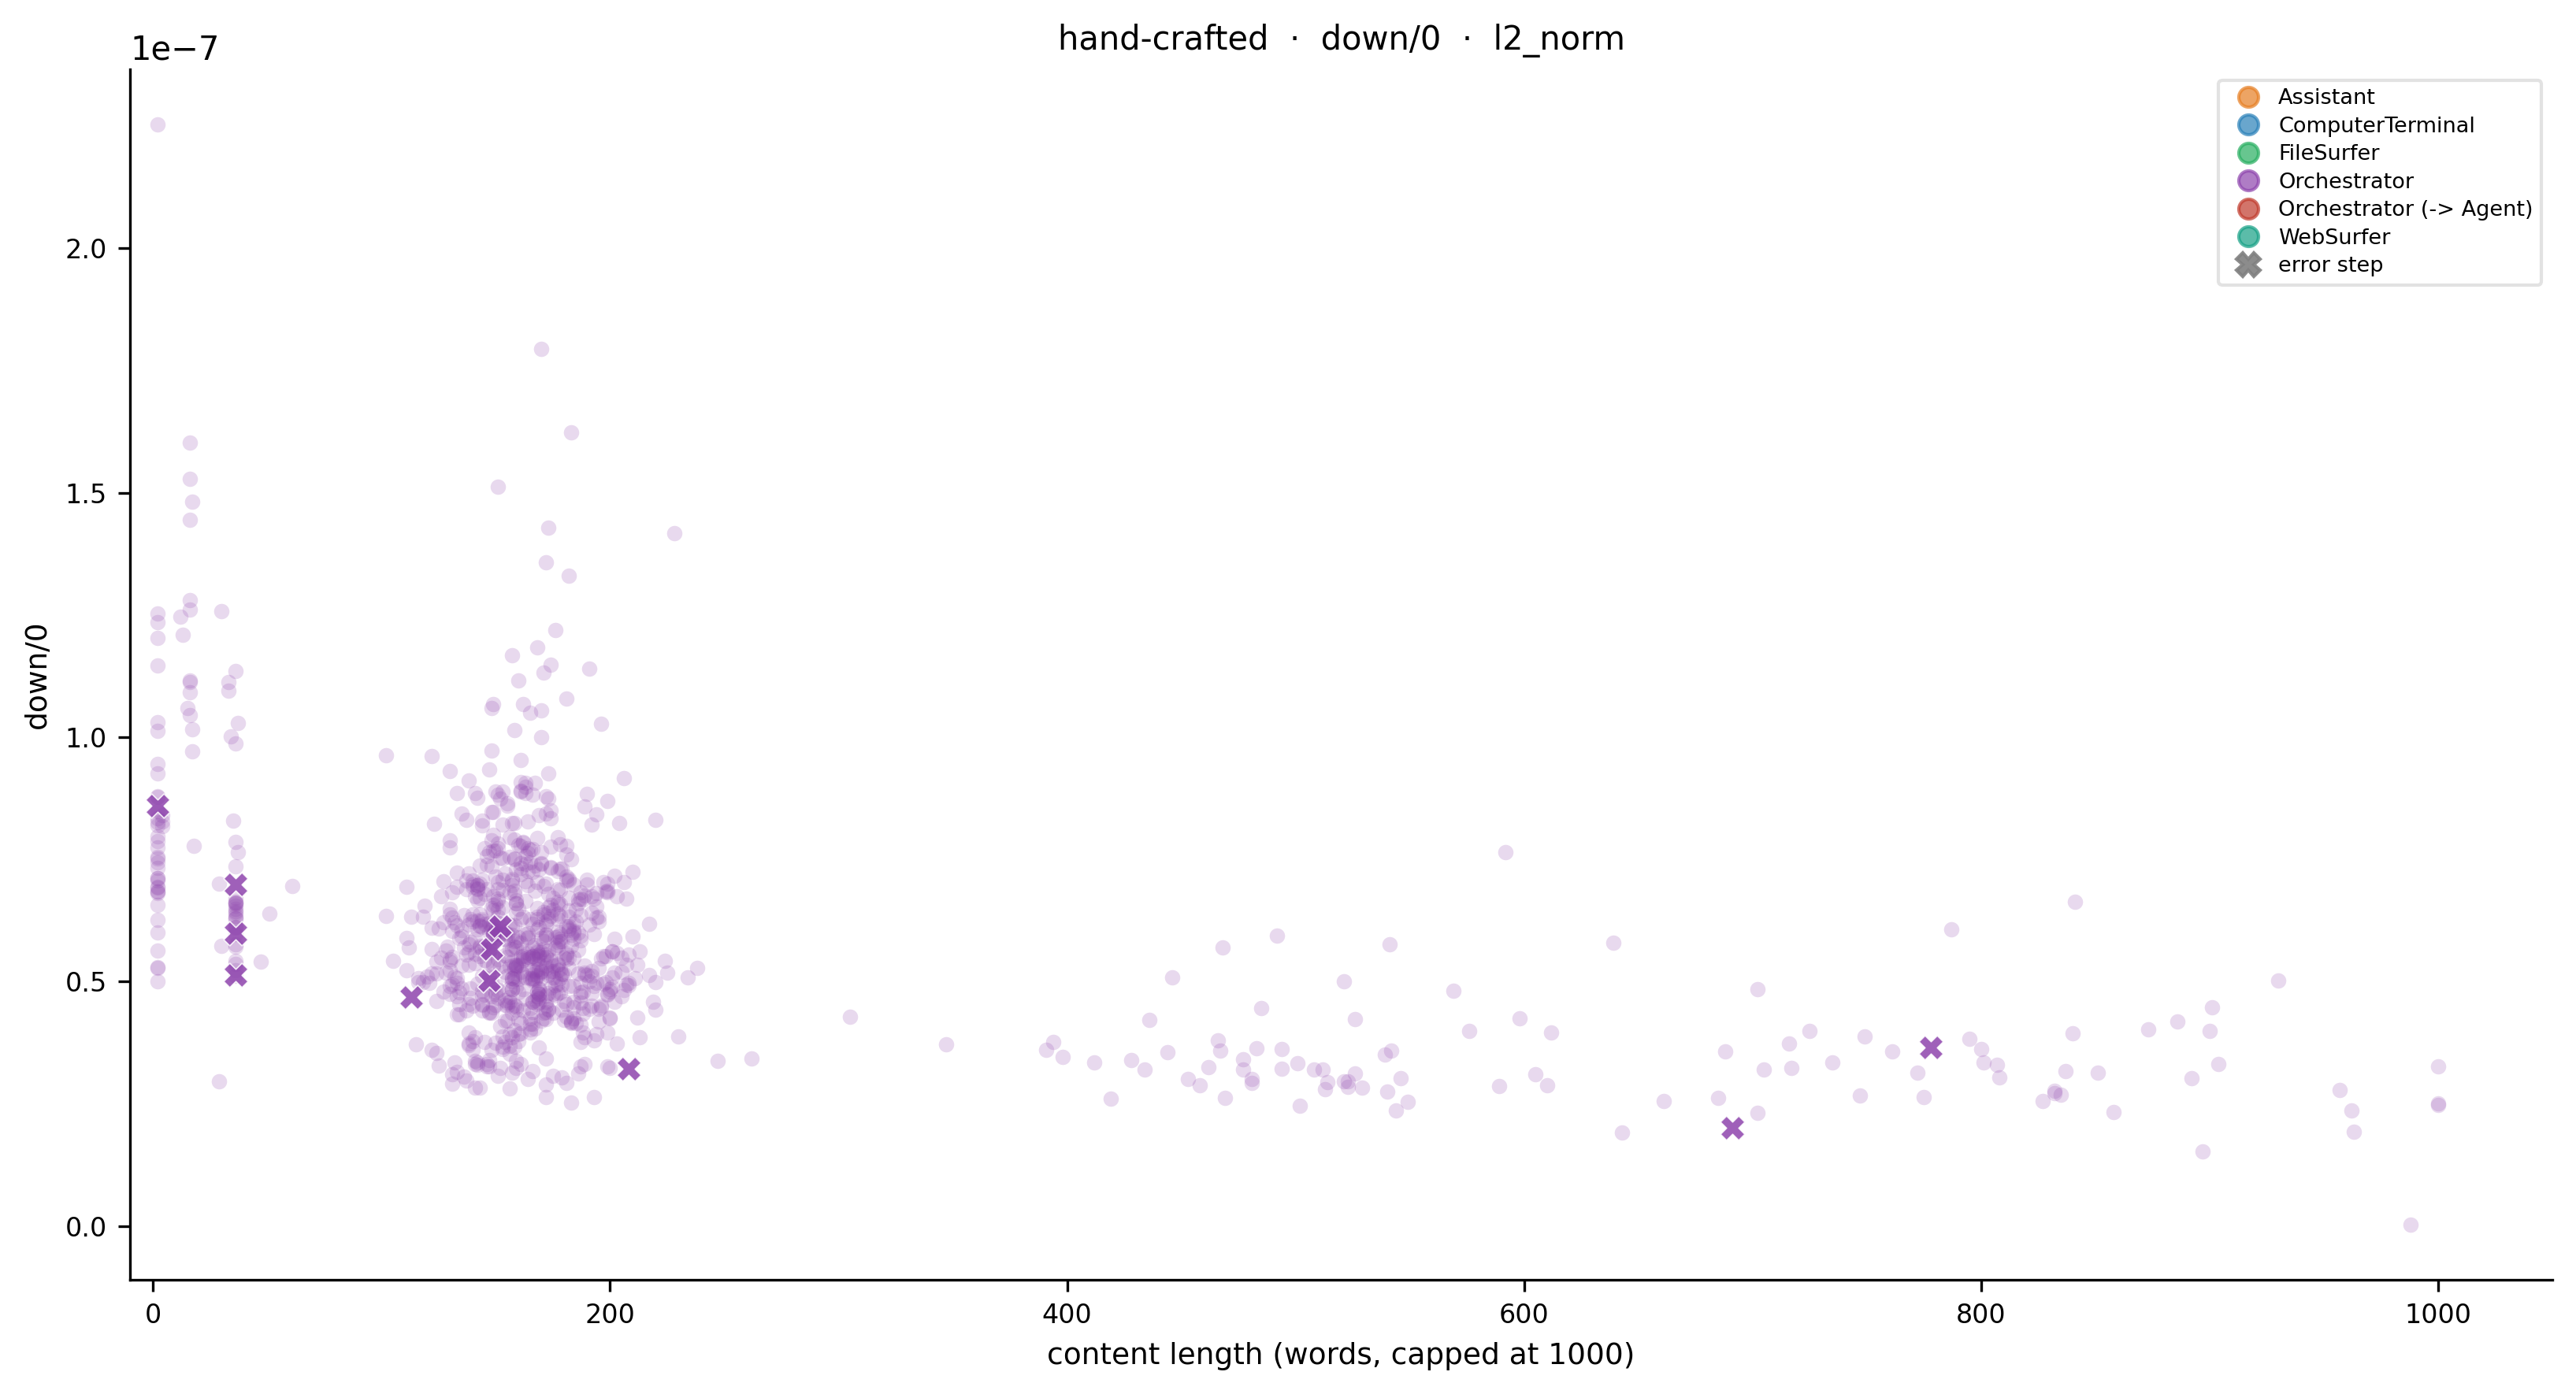

In [17]:
plot_records(records)

In [10]:
def plot_traj_scatter(traj_id, records, score_config, norm_type, length_cap=1000):
    traj_records = [
        r for r in records
        if r["traj_idx"] == traj_id
        and not r["content"].lower().startswith("next speaker")
    ]
    if not traj_records:
        print(f"No records for traj {traj_id}")
        return

    all_roles = sorted({normalise_role(r["role"]) for r in traj_records})
    role_color = {role: COLORS[i % len(COLORS)] for i, role in enumerate(all_roles)}

    xs_normal, ys_normal, cs_normal, ls_normal = [], [], [], []
    xs_err,    ys_err,    cs_err,    ls_err    = [], [], [], []

    for r in traj_records:
        role  = normalise_role(r["role"])
        x     = min(len(r["content"].split()), length_cap)
        y     = r["score"]
        c     = role_color[role]
        label = f"step {r['step_idx']}"
        if r["is_mistake"]:
            xs_err.append(x);    ys_err.append(y)
            cs_err.append(c);    ls_err.append(label)
        else:
            xs_normal.append(x); ys_normal.append(y)
            cs_normal.append(c); ls_normal.append(label)

    fig, ax = plt.subplots(figsize=(11, 6), dpi=300)

    if xs_normal:
        ax.scatter(xs_normal, ys_normal, c=cs_normal,
                   alpha=0.35, s=40, linewidths=0, zorder=2)
    if xs_err:
        ax.scatter(xs_err, ys_err, c=cs_err,
                   alpha=0.90, s=80, marker="X",
                   linewidths=0.4, edgecolors="white", zorder=4)

    # ── step index annotations ────────────────────────────────────────
    for r in traj_records:
        x = min(len(r["content"].split()), length_cap)
        y = r["score"]
        c = role_color[normalise_role(r["role"])]
        txt = ax.text(x, y, str(r["step_idx"]), fontsize=5.5,
                    ha="center", va="bottom", color=c,
                    fontweight="bold", zorder=5)
        txt.set_path_effects([pe.withStroke(linewidth=2, foreground="white")])

    # ── legend ────────────────────────────────────────────────────────
    from matplotlib.lines import Line2D
    handles = [
        Line2D([0],[0], marker="o", linestyle="", color=role_color[r],
               markersize=7, alpha=0.7, label=r)
        for r in all_roles
    ]
    handles.append(
        Line2D([0],[0], marker="X", linestyle="", color="gray",
               markersize=7, alpha=0.9, label="error step")
    )
    ax.legend(handles=handles, fontsize=7, frameon=True,
              framealpha=0.85, edgecolor="#dddddd",
              loc="upper right", handletextpad=0.4, labelspacing=0.35)

    ax.set_xlabel("content length (words, capped at 1000)", fontsize=9)
    ax.set_ylabel(score_config, fontsize=9)
    ax.set_title(f"traj {traj_id}  ·  {score_config}  ·  {norm_type}", fontsize=10)
    ax.set_xlim(-10, length_cap + 50)
    ax.tick_params(labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    # plt.savefig(f"scatter_traj{traj_id}_{score_config.replace('/','-')}_{norm_type}.png",
    #             dpi=300, bbox_inches="tight")
    plt.show()

In [12]:
def plot_traj(traj_id, records, score_config, norm_type, k=3, ax=None):
    traj_records = sorted(
        [r for r in records if r["traj_idx"] == traj_id],
        key=lambda r: r["step_idx"],
    )

    # ── exclude "next speaker" steps ─────────────────────────────────
    traj_records = [
        r for r in traj_records
        if not r["content"].lower().startswith("next speaker")
    ]
    if not traj_records:
        return

    steps      = [r["step_idx"]   for r in traj_records]
    scores     = [r["score"]      for r in traj_records]
    roles      = [r["role"]       for r in traj_records]
    is_mistake = [r["is_mistake"] for r in traj_records]

    # ── use positional x so axis is dense (no gaps for excluded steps) 
    pos = list(range(len(steps)))

    score_arr   = np.array(scores)
    order       = np.argsort(score_arr)
    low_idx     = set(order[:k].tolist())
    high_idx    = set(order[-k:].tolist())
    mistake_idx = {i for i, m in enumerate(is_mistake) if m}

    def dot_color(i):
        if i in low_idx:   return "#2ecc71"
        if i in high_idx:  return "#3498db"
        return "#aaaaaa"

    colors = [dot_color(i) for i in range(len(pos))]

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(max(10, len(pos) * 0.45), 4))

    ax.plot(pos, scores, color="#cccccc", lw=1.2, zorder=1)

    # ── split into normal (circle) and mistake (square) ───────────────
    normal_pos = [p for i, p in enumerate(pos) if i not in mistake_idx]
    normal_scores = [scores[i] for i in range(len(pos)) if i not in mistake_idx]
    normal_colors = [colors[i] for i in range(len(pos)) if i not in mistake_idx]

    mistake_pos = [p for i, p in enumerate(pos) if i in mistake_idx]
    mistake_scores = [scores[i] for i in range(len(pos)) if i in mistake_idx]
    mistake_colors = [colors[i] for i in range(len(pos)) if i in mistake_idx]

    if normal_pos:
        ax.scatter(normal_pos, normal_scores,
                   c=normal_colors, s=55, marker="o",
                   zorder=3, edgecolors="white", linewidths=0.6)
    if mistake_pos:
        ax.scatter(mistake_pos, mistake_scores,
                   c=mistake_colors, s=90, marker="s",
                   zorder=3, edgecolors="red", linewidths=0.6)

    # ── labels ────────────────────────────────────────────────────────
    for i, (p, y, role) in enumerate(zip(pos, scores, roles)):
        txt = ax.text(p, y, role, fontsize=6.5, ha="center", va="bottom",
                      color=colors[i], fontweight="bold")
        txt.set_path_effects([pe.withStroke(linewidth=2, foreground="white")])

    # ── x-axis: tick at every position, labelled with actual step_idx ─
    ax.set_xticks(pos)
    ax.set_xticklabels(steps, fontsize=5.5, rotation=90)
    ax.set_xlabel("step", fontsize=9)
    ax.set_ylabel(score_config, fontsize=9)
    ax.set_title(f"traj {traj_id}", fontsize=10)
    ax.tick_params(axis="y", labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)

    if standalone:
        from matplotlib.lines import Line2D
        ax.legend(handles=[
            Line2D([0],[0], marker="s", color="w", markerfacecolor="#aaaaaa", markersize=7, label="mistake"),
            Line2D([0],[0], marker="o", color="w", markerfacecolor="#2ecc71", markersize=7, label=f"lowest {k}"),
            Line2D([0],[0], marker="o", color="w", markerfacecolor="#3498db", markersize=7, label=f"highest {k}"),
        ], fontsize=8, frameon=False, loc="upper left")
        plt.tight_layout()
        plt.show()

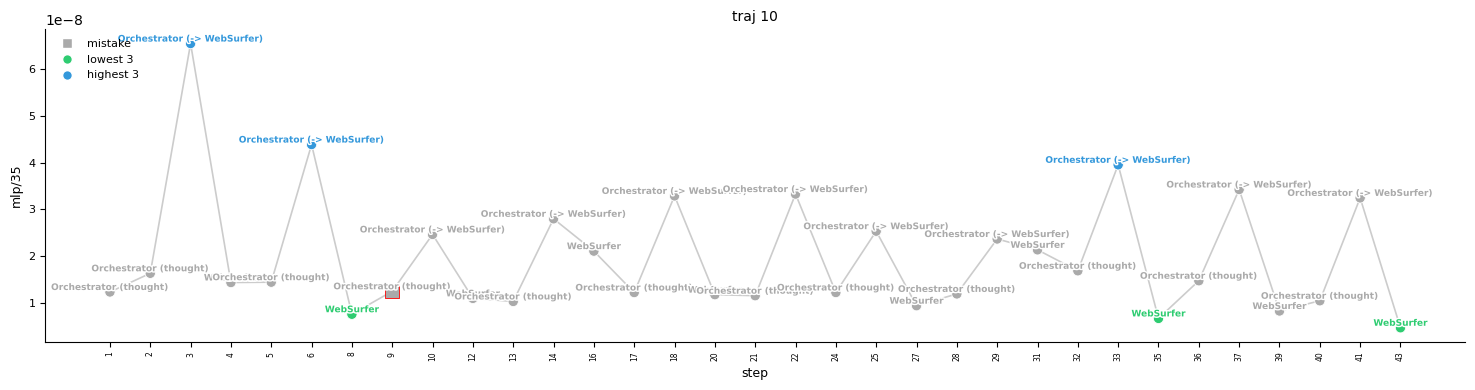

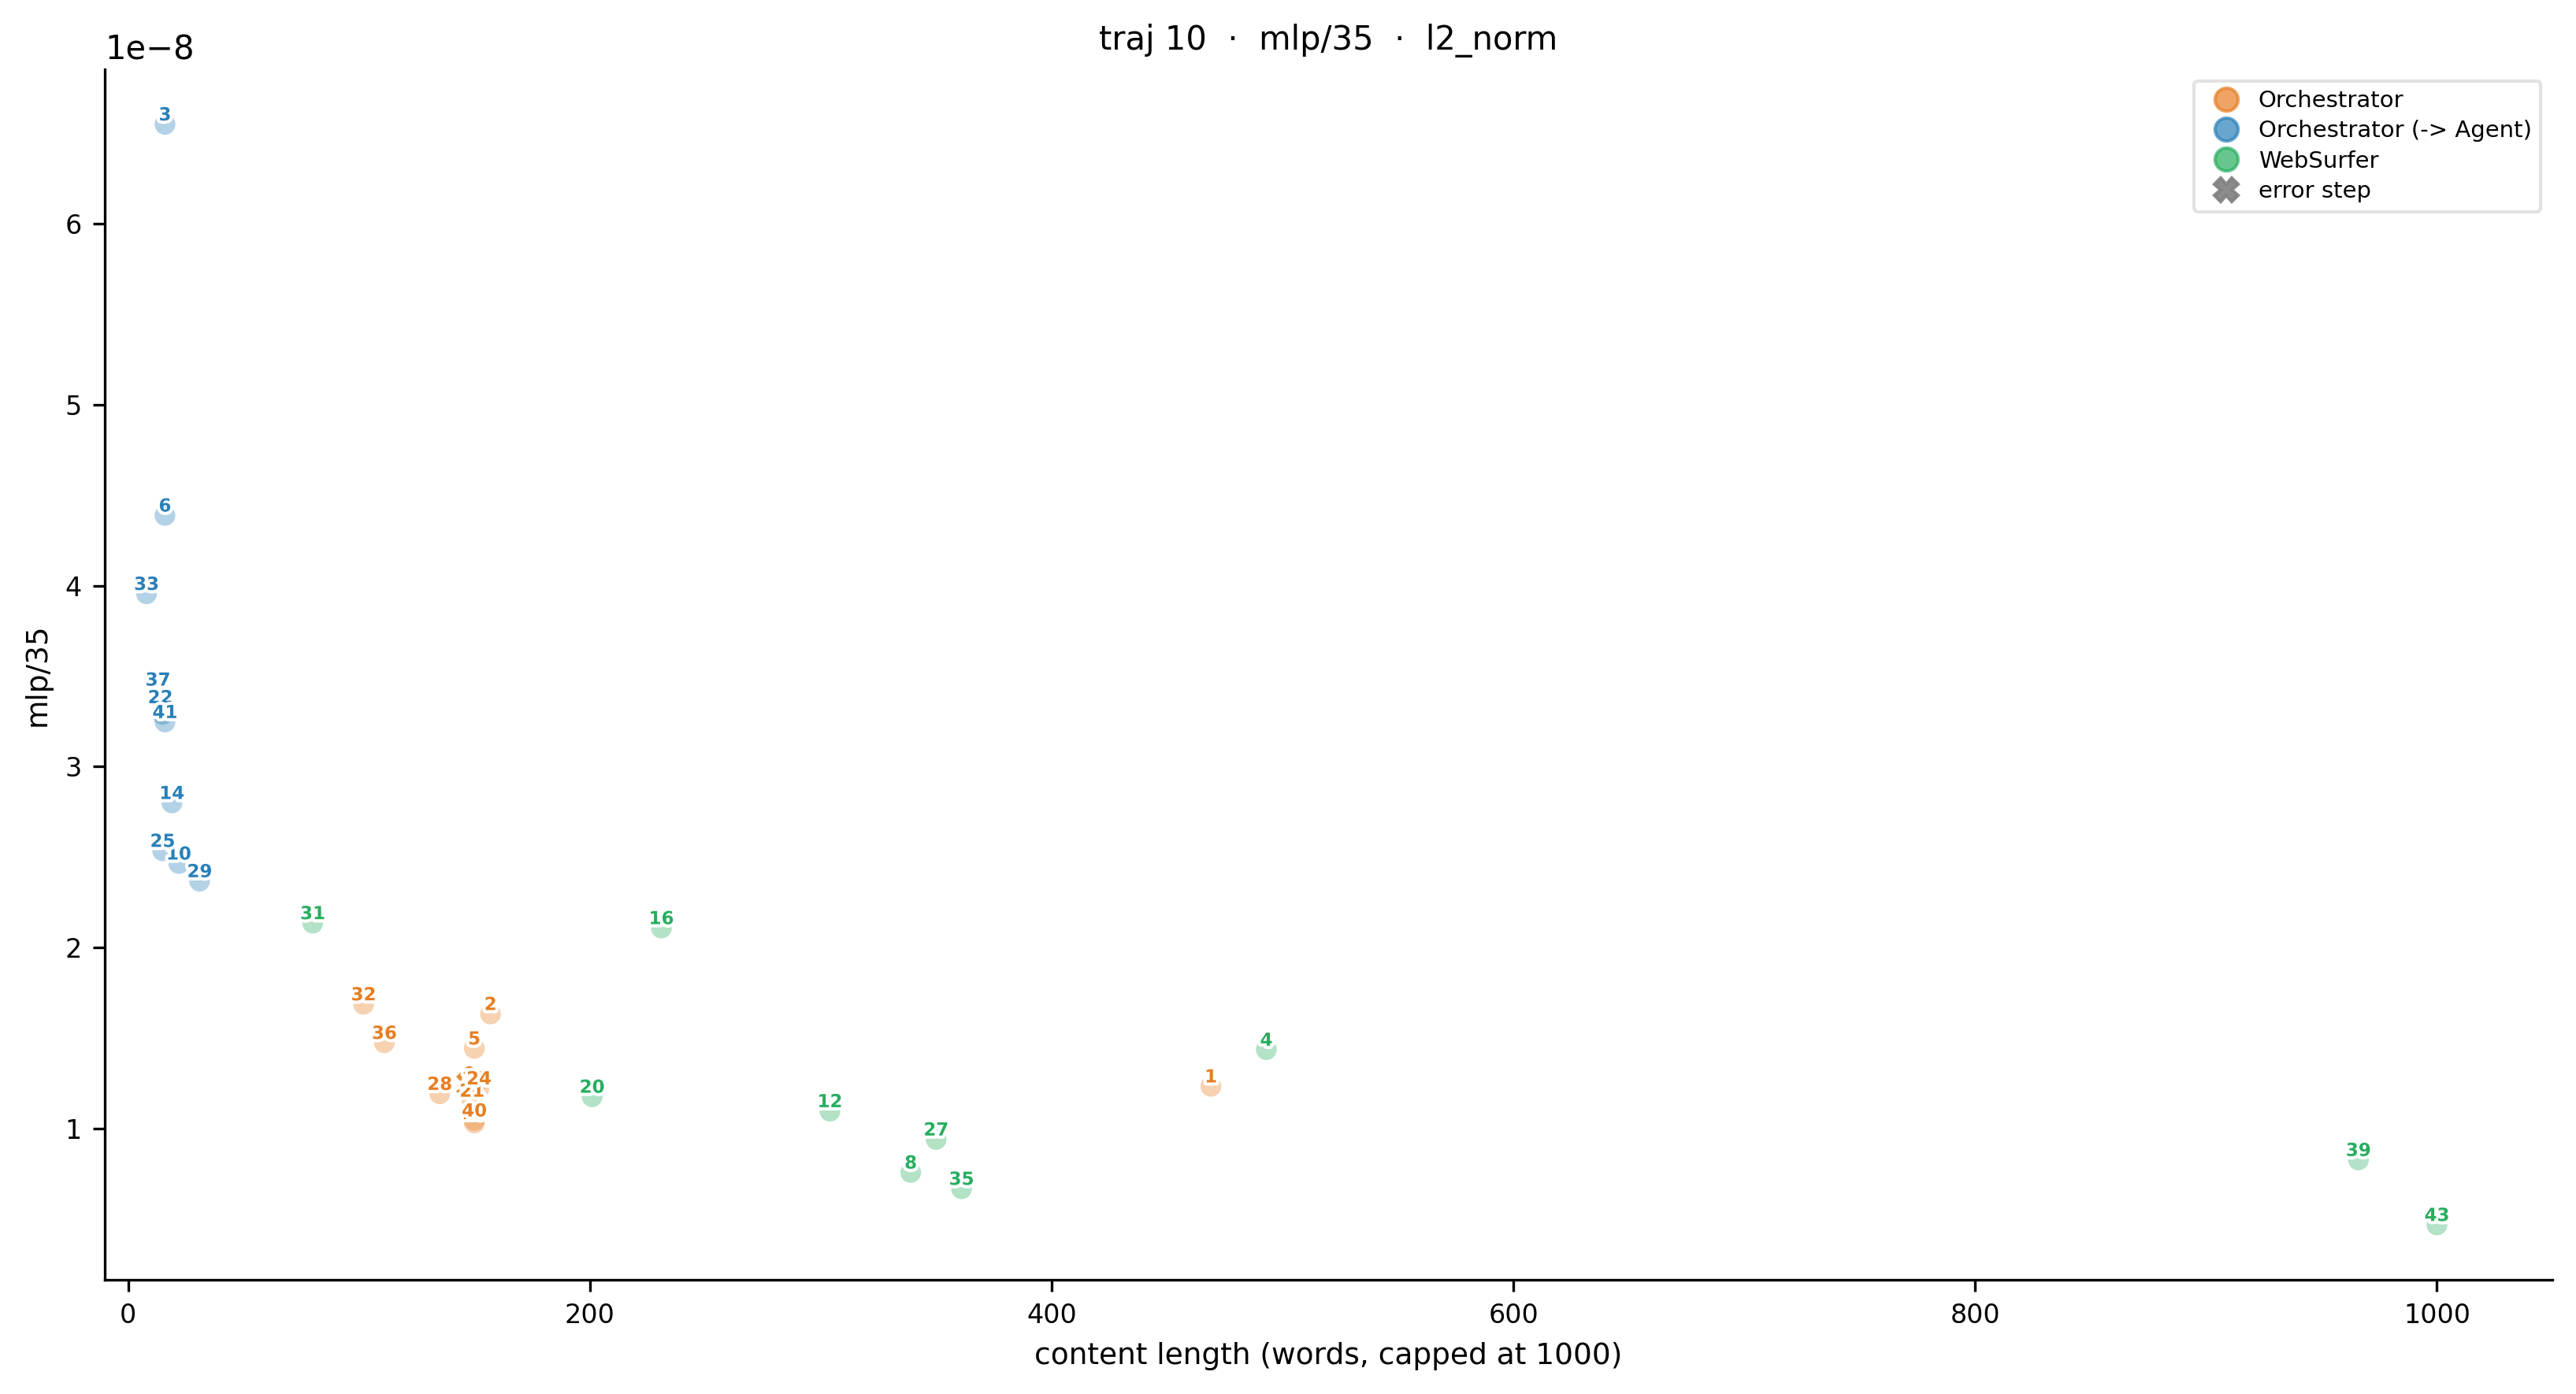

In [19]:
TRAJ_IDX = 10
plot_traj(TRAJ_IDX, records, SCORE_CONFIG, NORM_TYPE)
plot_traj_scatter(TRAJ_IDX, records, SCORE_CONFIG, NORM_TYPE)

In [7]:
traj = [x for x in records if x['traj_idx'] == 1]
target_idxs = [8]
step = [x for x in traj if x["step_idx"] in target_idxs][0]

# print(step['content'])

In [19]:
from gradnorm.eval import score_step

def predict_agents(records, norm_type=NORM_TYPE):
    """Return {traj_idx: predicted_agent} using lowest-score step."""
    from collections import defaultdict

    traj_steps = defaultdict(list)
    for r in records:
        traj_steps[r["traj_idx"]].append(r)

    predictions = {}
    for traj_idx, steps in traj_steps.items():
        valid = [r for r in steps if not np.isnan(r["score"])]
        if not valid:
            continue
        best = min(valid, key=lambda r: r["score"])
        predictions[traj_idx] = best["role"]

    return predictions

predictions = predict_agents(records)
predictions

{1: 'WebSurfer',
 10: 'WebSurfer',
 11: 'Orchestrator (thought)',
 12: 'WebSurfer',
 13: 'Orchestrator (thought)',
 14: 'Orchestrator (thought)',
 15: 'WebSurfer',
 16: 'WebSurfer',
 17: 'WebSurfer',
 18: 'WebSurfer',
 19: 'WebSurfer',
 2: 'WebSurfer',
 20: 'WebSurfer',
 21: 'WebSurfer',
 22: 'WebSurfer',
 23: 'WebSurfer',
 24: 'Orchestrator (thought)',
 25: 'WebSurfer',
 26: 'Orchestrator (thought)',
 27: 'WebSurfer',
 28: 'WebSurfer',
 29: 'WebSurfer',
 3: 'WebSurfer',
 30: 'WebSurfer',
 31: 'WebSurfer',
 32: 'Orchestrator (thought)',
 33: 'WebSurfer',
 34: 'WebSurfer',
 35: 'WebSurfer',
 36: 'WebSurfer',
 37: 'WebSurfer',
 38: 'WebSurfer',
 39: 'Orchestrator (thought)',
 4: 'WebSurfer',
 40: 'WebSurfer',
 41: 'WebSurfer',
 42: 'WebSurfer',
 43: 'WebSurfer',
 44: 'WebSurfer',
 45: 'Orchestrator (thought)',
 46: 'WebSurfer',
 47: 'Orchestrator (thought)',
 48: 'WebSurfer',
 49: 'WebSurfer',
 5: 'WebSurfer',
 50: 'WebSurfer',
 51: 'WebSurfer',
 52: 'WebSurfer',
 53: 'WebSurfer',
 54: '

In [21]:
step

{'traj_idx': 1,
 'step_idx': 6,
 'score': 2.5625462765957704e-08,
 'is_mistake': False,
 'role': 'Orchestrator (-> WebSurfer)',
 'content': 'Please visit the websites or listings of the martial arts schools mentioned in the search results and note down their addresses and class schedules (specifically from 7-9 pm). Verify whether they are within a five-minute walk from the New York Stock Exchange.',
 'reason': None}

In [42]:
traj_t = [x for x in records if x["traj_idx"] == 6]
[x['is_mistake'] for x in traj_t]

[False, False, False, False, True, False, False]

In [31]:
shorts = [x for x in records if len(x["content"].split()) > 500]

In [35]:
long_orch = [x for x in records if len(x["content"].split()) < 400 and x['role'].lower().startswith("orchestrator")]